# Metody analizy danych. Lab 7. Biblioteka matplotlib, część 1

## **1. Wprowadzenie**

Na początku warto zapoznać się z nazewnictwem (angielskim) elementów, z których składa się widok wykresu. Poniższa grafika pozwoli na ich identyfikację i możliwość dostosowania wykresu do założeń lub potrzeb danego zadania/problemu.

![Anatomia wykresów](./images/anatomy.png)

In [2]:
import matplotlib.pyplot as plt

## 2. Wybrane typy wykresów

### 2.1 Wykres liniowy

> Dokumentacja: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

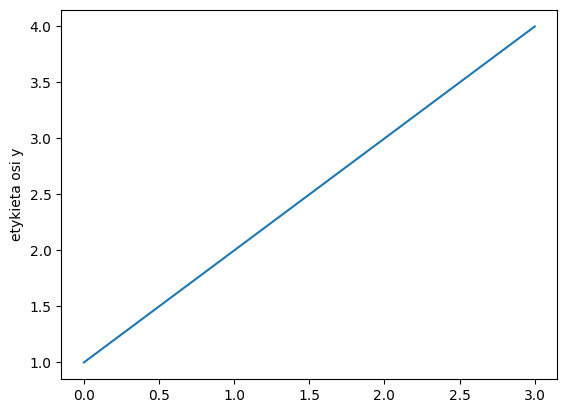

In [3]:
# listnig 1

plt.plot([1, 2, 3, 4])
plt.ylabel('etykieta osi y')
plt.show()

Powyższy kod jest w postaci, która używana jest zazwyczaj w tradycyjnych skryptach języka Python. Jupyter Notebook posiada specjalny backend i metody magiczne, które mają zazwyczaj dodatkowe działanie w notatnikach. Pakiet `matplotlib` również może zostać użyty z wykorzystaniem takiego backendu (więcej tutaj: [https://ipython.readthedocs.io/en/stable/interactive/plotting.html](https://ipython.readthedocs.io/en/stable/interactive/plotting.html).
Zwalnia nas to z obowiązku używania `plt.show()`, ale wypisuje też na wyjściu reprezentację łańcuchową ostatniej linii kodu (obiektu). Można tego uniknąć, przypisując tę instrukcję do zmiennej lub dodając znak `;` na końcu kodu.

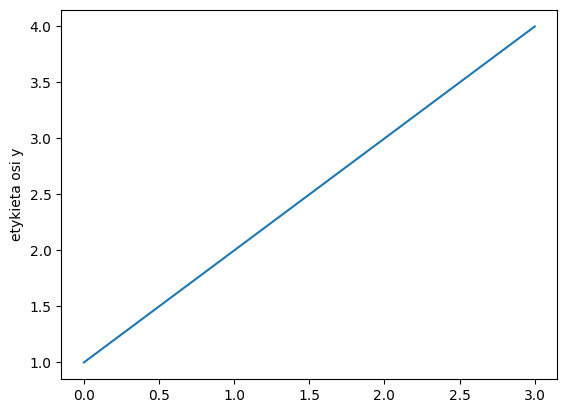

In [4]:
# listing 2

# aktywacja backendu liniowego dla pakietu matplotlib
%matplotlib inline

plt.ylabel('etykieta osi y')
plt.plot([1, 2, 3, 4]);

Wektor przekazanych wartości to oś `Y`, a oś `X` została wygenerowana automatycznie i tutaj dla wartości z wektora `Y` przyjmuje po prostu wartość indeksu z tej listy, czyli dla wartości 1 przyjmuje wartość 0 itd.

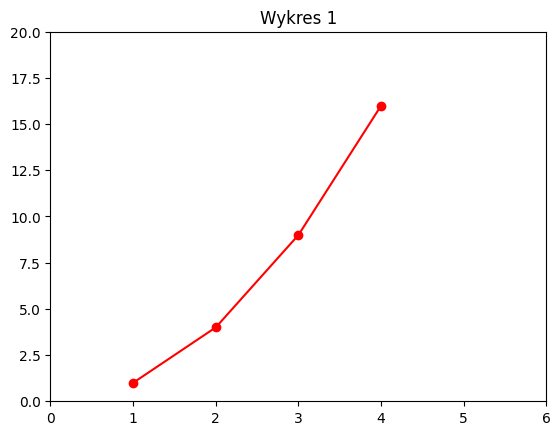

(np.float64(0.0), np.float64(6.0), np.float64(0.0), np.float64(20.0))

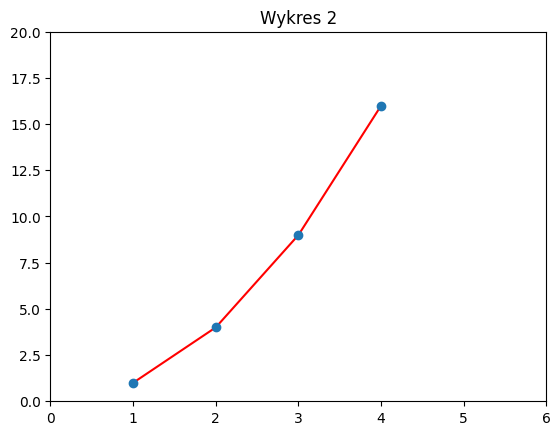

In [5]:
# listing 3

# przekazujemy dwa wektory wartości, najpierw dla wektora x, następnie y
# dodatkowo mamy tutaj przekazany parametr w postaci stringa, który określa styl wykresu
# dla pełnej listy sprawdź dokumentację pod adresem
# https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot
plt.plot([1, 2, 3, 4], [1, 4, 9, 16], 'ro-')
# tutaj określamy listę parametrów w postaci [xmin, xmax, ymin, ymax]
plt.axis([0, 6, 0, 20])
plt.title('Wykres 1')
plt.show()

# możemy też ustawiać różne kolory dla poszczególnych elementów nakładając na siebie dwa wykresy
plt.plot([1, 2, 3, 4], [1, 4, 9, 16], 'r')
plt.plot([1, 2, 3, 4], [1, 4, 9, 16], 'o')
plt.title('Wykres 2')

plt.axis([0, 6, 0, 20])

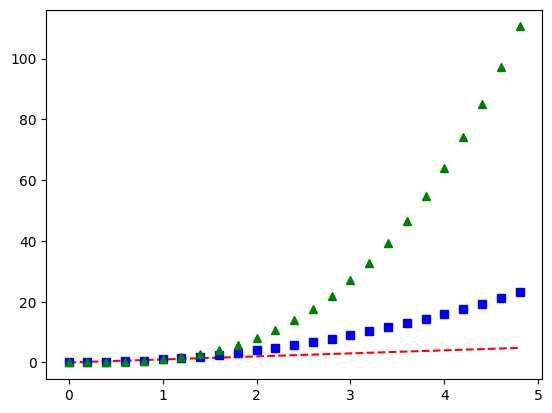

In [6]:
# listing 4
import numpy as np

# bazowy wektor wartości
t = np.arange(0., 5., 0.2)

# za pomocą pojedynczego wywołania funkcji plot() możemy wygenerować wiele wykresów na jednym "płótnie" (ang. canvas)
# każdorazowo podając niezbędne wartości: wartości dla osi x, wartości dla osi y, styl wykresu, ...
plt.plot(t, t, 'r--', t, t**2, 'bs', t, t**3, 'g^');

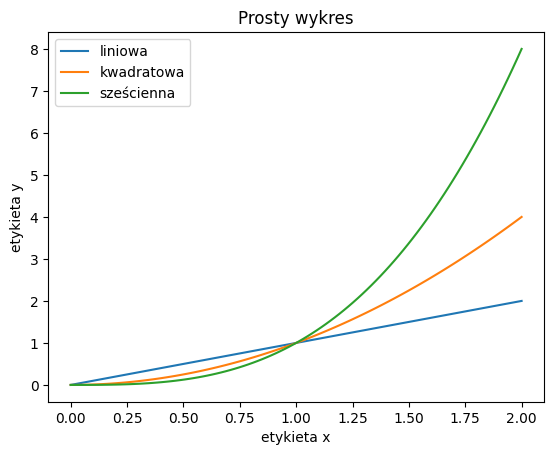

In [7]:
# listing 5
x = np.linspace(0, 2, 100)

# wykresy mogą być też dodawane do płótna definicja po definicji zamiast w pojedynczym wywołaniu funkcji plot()
# tutaj użyty został również parametr label, który określa etykietę danego wykresu w legendzie
plt.plot(x, x, label='liniowa')
plt.plot(x, x**2, label='kwadratowa')
plt.plot(x, x**3, label='sześcienna')

# etykiety osi
plt.xlabel('etykieta x')
plt.ylabel('etykieta y')

# tytuł wykresu
plt.title("Prosty wykres")

# włączamy pokazywanie legendy
plt.legend();

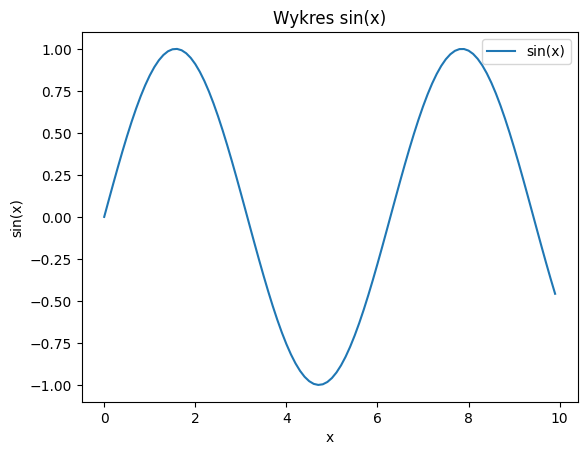

In [8]:
# listing 6

x = np.arange(0, 10, 0.1)
s = np.sin(x)
plt.plot(x, s, label='sin(x)')

# etykiety osi
plt.xlabel('x')
plt.ylabel('sin(x)')

# tytuł wykresu
plt.title("Wykres sin(x)")

# umieszczamy legendę na wykresie
plt.legend();

### 2.2. Wykres punktowy (ang. scatter plot)

> Dokumentacja: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html

a=0, b=5.744723272451625, c=20, d=112.97884062537985


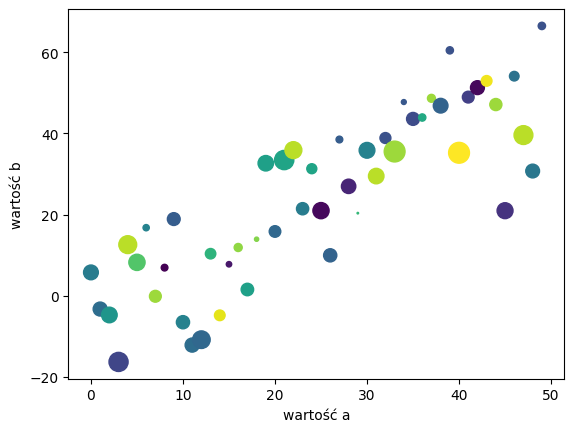

In [9]:
# listing 7

# dane w formie słownika, ale równie dobrze może to być Pandas DataFrame
data = {'a': np.arange(50),
        'c': np.random.randint(0, 50, 50),
        'd': np.random.randn(50)}
data['b'] = data['a'] + 10 * np.random.randn(50)
data['d'] = np.abs(data['d']) * 100

# aby w ten sposób przekazać parametry wykresu należy dodać niezbędny parametr data, który zawiera dane dostępne poprzez etykiety
# to oznacza, że 'a' jest równoważne data['a'] itd. Parametr c to skrót od color, tutaj przekazywany w formie wektora
# wartości kolorów dla każdej kolejnej wartości wykresu. Parametr s to scale - określa rozmiar, w tym przypadku punktu, dla
# każdej kolejnej wartości wektora wykresu. Reasumując dla pierwszego punktu wykresu będą brane poniższe wartości
print(f"a={data['a'][0]}, b={data['b'][0]}, c={data['c'][0]}, d={data['d'][0]}")
plt.scatter('a', 'b', c='c', s='d', data=data)
plt.xlabel('wartość a')
plt.ylabel('wartość b');

### 2.3 Podwykresy

Podwykresy pozwalają na umieszczanie na jednym płótnie wielu wykresów zorganizowanych w formie gridu. Podajemy wymiary gridu, czyli liczbę wierszy oraz liczbę kolumn. Służy to tego funkcja subplot, która przyjmuje 3 argumenty (`nrows, ncols, index`). Odpowiednio jest to ilość wierszy gridu, ilość kolumn oraz indeks definiowanego właśnie wykresu (indeksy rozpoczynają się od 1 i kończą na `nrows*ncols`).

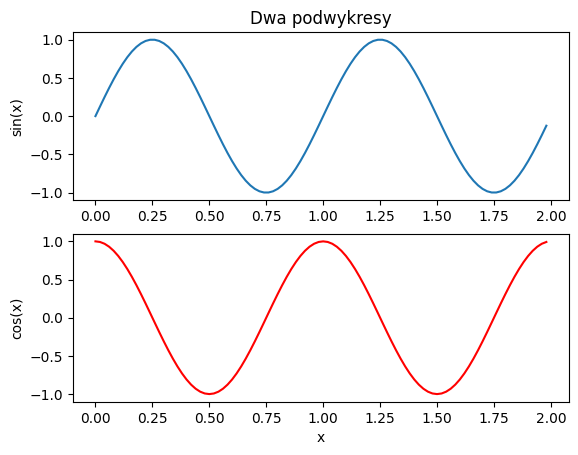

In [10]:
# listing 8

x1 = np.arange(0.0, 2.0, 0.02)
x2 = np.arange(0.0, 2.0, 0.02)

y1 = np.sin(2 * np.pi * x1)
y2 = np.cos(2 * np.pi * x2)


plt.subplot(2, 1, 1)
plt.plot(x1, y1, '-')
plt.title('Dwa podwykresy')
plt.ylabel('sin(x)')

plt.subplot(2, 1, 2)
plt.plot(x2, y2, 'r-')
plt.xlabel('x')
plt.ylabel('cos(x)');

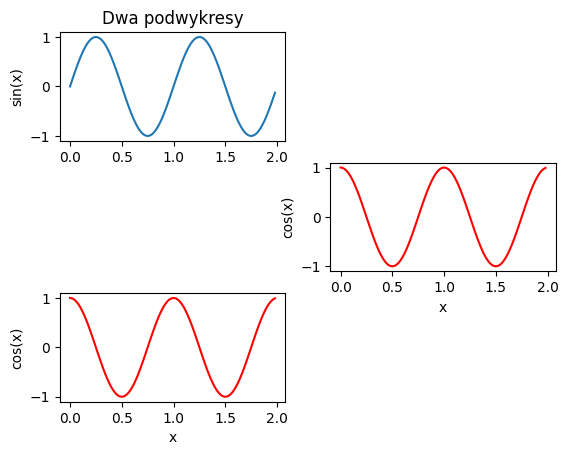

In [11]:
# listing 9
# inny przykład podwykresów

x1 = np.arange(0.0, 2.0, 0.02)
x2 = np.arange(0.0, 2.0, 0.02)
y1 = np.sin(2 * np.pi * x1)
y2 = np.cos(2 * np.pi * x2)

# oznacza, że mamy tutaj do czynienia z gridem 3x2 (3 wiersze, 2 kolumny) i definiujemy wykres o indeksie 1
plt.subplot(3, 2, 1)
plt.plot(x1, y1, '-')
plt.title('Dwa podwykresy')
plt.ylabel('sin(x)')

# możemy również pominąć przecinki, tu wykres o indeksie 4, więc pominęliśmy 2 oraz 3
plt.subplot(324)
plt.plot(x2, y2, 'r-')
plt.xlabel('x')
plt.ylabel('cos(x)')

plt.subplot(3, 2, 5)
plt.plot(x2, y2, 'r-')
plt.xlabel('x')
plt.ylabel('cos(x)');

### 2.4 Wykres słupkowy

> Dokumentacja:
> * pionowy: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html
> * poziomy: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.barh.html

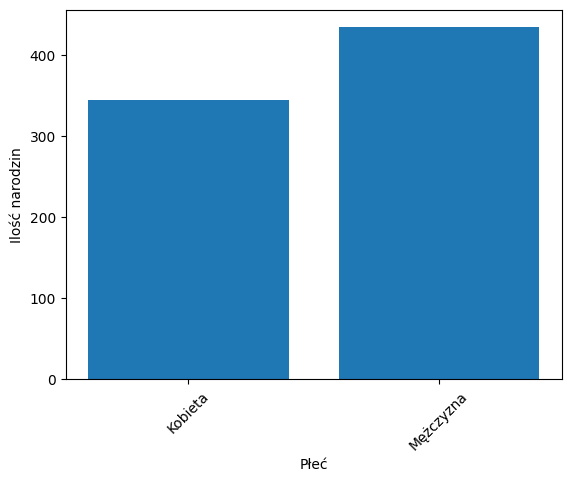

In [12]:
# listing 10
# poniższy listing przedstawia prosty przykład wykresu słupkowego.

etykiety = ['Kobieta', 'Mężczyzna']
wartosci = [345, 435]

plt.bar(etykiety, wartosci)
# możemy również zmienić np. kierunek tekstu etykiet słupków, żeby zaoszczędzić trochę miejsca
plt.xticks(rotation=45)
plt.ylabel('Ilość narodzin')
plt.xlabel('Płeć');

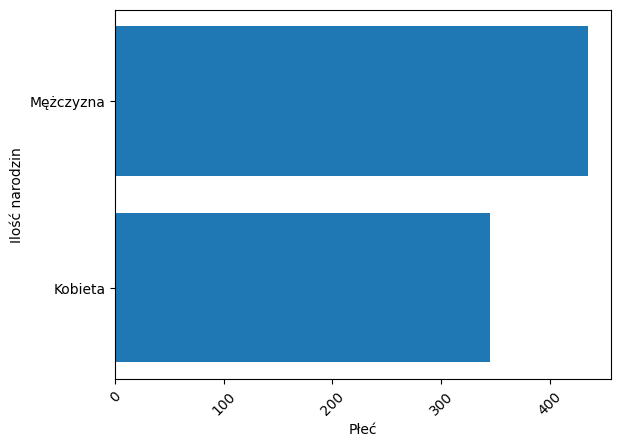

In [13]:
# to samo, ale w postaci wykresu słupkowego poziomego

etykiety = ['Kobieta', 'Mężczyzna']
wartosci = [345, 435]

plt.barh(etykiety, wartosci)
# możemy również zmienić np. kierunek tekstu etykiet słupków, żeby zaoszczędzić trochę miejsca
plt.xticks(rotation=45)
plt.ylabel('Ilość narodzin')
plt.xlabel('Płeć');

### 2.5 Wykres typu histogram

> Dokumentacja: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html

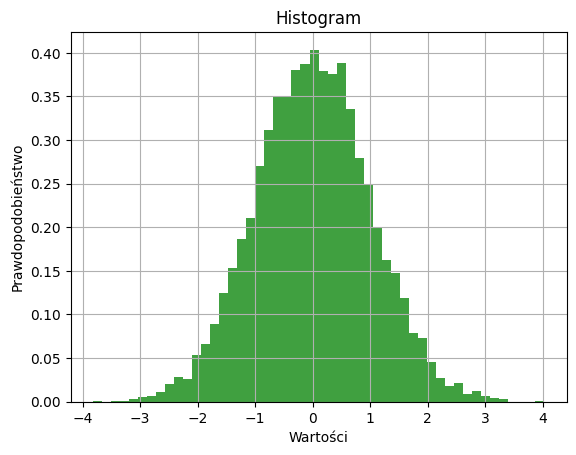

In [14]:
# listing 11
# generujemy próbkę wartości z rozkładu normalnego
x = np.random.randn(10000)

# bins oznacza ilość "koszy" czyli słupków, do których mają wpadać wartości z wektora x
# facekolor oznacza kolor słupków
# alpha to stopień przezroczystości wykresu
# density oznacza czy suma ilości zostanie znormalizowana do rozkładu prawdopodobieństwa (czyli przedział 0, 1)
plt.hist(x, bins=50, facecolor='g', alpha=0.75, density=True)
# plt.hist(x, bins=50, facecolor='g', alpha=0.75)

plt.xlabel('Wartości')
plt.ylabel('Prawdopodobieństwo')
plt.title('Histogram')
# wyświatlanie siatki
plt.grid(True)

### 2.6 Wykres kołowy

> Dokumentacja: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html

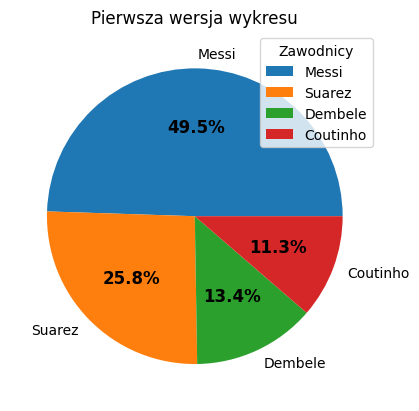

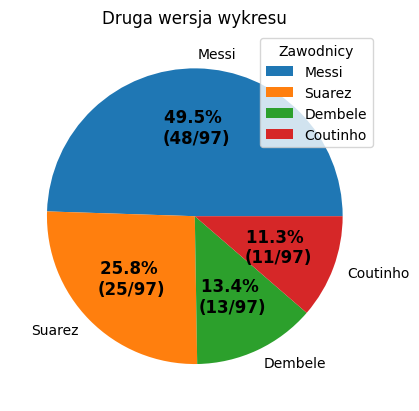

In [15]:
# listing 12

zawodnicy = ['Messi', 'Suarez', 'Dembele', 'Coutinho']
bramki = [48, 25, 13, 11]

# pierwsza wersja wykresu
wedges, texts, autotexts = plt.pie(bramki, labels=zawodnicy,
                                   autopct=lambda pct: "{:.1f}%".format(pct), textprops=dict(color="black"))
plt.setp(autotexts, size=12, weight="bold")
plt.title("Pierwsza wersja wykresu")
plt.legend(title='Zawodnicy')
plt.show()

# druga wersja wykresu
def prepare_label(pct, br):
    absolute = int(np.ceil(pct / 100. * np.sum(br)))
    return "{:.1f}% \n({}/{})".format(pct, absolute, sum(bramki))


wedges, texts, autotexts = plt.pie(bramki, labels=zawodnicy,
                                   autopct=lambda pct: prepare_label(pct, bramki), textprops=dict(color="black"))
plt.setp(autotexts, size=12, weight="bold")
plt.title("Druga wersja wykresu")

# więcej o parametrach legendy wykresów znajdziesz pod adresem
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html
plt.legend(title='Zawodnicy', loc='best');

### 3. Przykład wykresu z ramki pandas

Biblioteka matplotlib jest biblioteką niskopoziomową w porównaniu do bibliotek, które zostaną przedstawione na kolejnych zajęciach (seaborn, bokeh, plotly) i wymaga nieco więcej pracy w procesie przygotowania i selekcji danych do wykresu. Przykład zostanie zaprezentowany na bazie danych ze zbioru `zamowienia.csv`.

In [16]:
# wczytujemy dane
import pandas as pd

df_zam = pd.read_csv(r'https://raw.githubusercontent.com/kropiak/swps-metody-analizy-danych/refs/heads/main/lab_06/data/zamowienia.csv', sep=';')
df_zam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Kraj             799 non-null    object 
 1   Sprzedawca       799 non-null    object 
 2   Data zamowienia  799 non-null    object 
 3   idZamowienia     799 non-null    int64  
 4   Utarg            799 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 31.3+ KB


<Axes: >

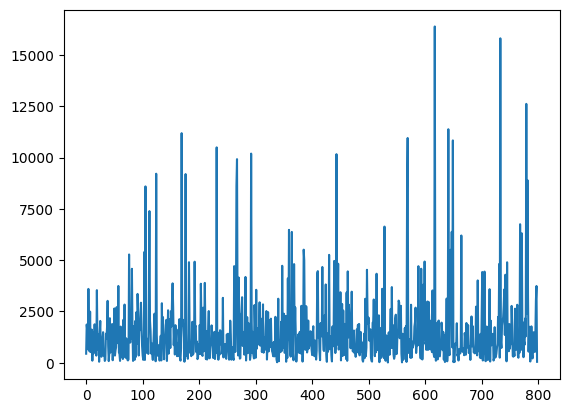

In [17]:
# zobaczmy bardzo prosty wykres dla kolumny Utarg
df_zam['Utarg'].plot()

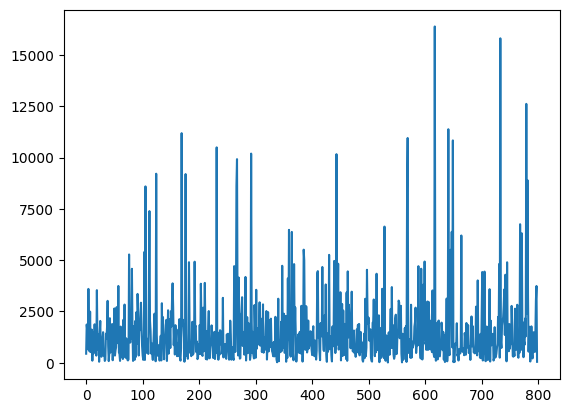

In [18]:
# lub tak
plt.plot(df_zam['Utarg'])

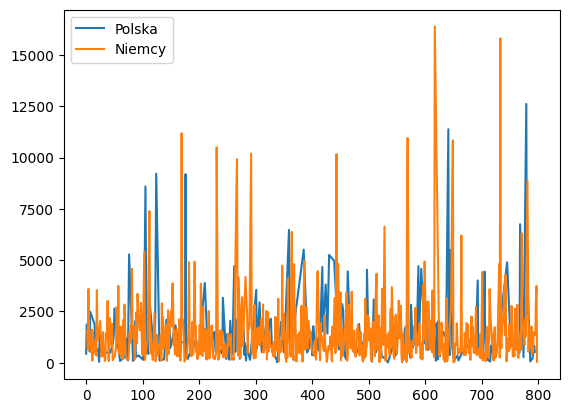

In [19]:
# rozważmy teraz przykład, w którym chcielibyśmy wyświetlić dwie serie danych (dwie linie na jednym wykresie) dla każdego kraju z osobna
plt.plot(df_zam[df_zam['Kraj'] == 'Polska']['Utarg'])
plt.plot(df_zam[df_zam['Kraj'] == 'Niemcy']['Utarg'])
plt.legend(['Polska','Niemcy'])

In [20]:
# teraz chcielibyśmy zrobić to samo, ale dla każdego roku z osobna (i kraju) licząc sumę utargu
# najwygodniej będzie przygotować dane w postaci ramki zgrupowanej z agregacją

# krok 1 - zamienimy kolumnę Data zamowienia na tym datetime, co znacznie ułatwi operowanie na składowych daty (i np. grupowanie po roku, miesiącu, itp.)
df_zam['Data zamowienia'] = pd.to_datetime(df_zam['Data zamowienia'])
df_zam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Kraj             799 non-null    object        
 1   Sprzedawca       799 non-null    object        
 2   Data zamowienia  799 non-null    datetime64[ns]
 3   idZamowienia     799 non-null    int64         
 4   Utarg            799 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 31.3+ KB


In [21]:
# krok 2 - grupujemy dane i liczymu sumę dla każdej grupy (czyli kraju i roku)
df_zam_sum_by_year = df_zam.groupby([df_zam['Data zamowienia'].dt.year, 'Kraj']).agg({'Utarg': ['sum']})
df_zam_sum_by_year

Utarg
                              sum
Data zamowienia Kraj             
2003            Niemcy  136002.99
                Polska   57313.55
2004            Niemcy  452347.15
                Polska  156843.61
2005            Niemcy  306646.35
                Polska  119173.75

<Axes: xlabel='Data zamowienia,Kraj'>

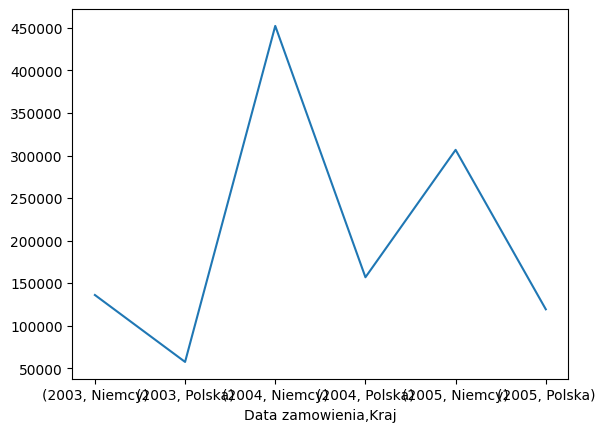

In [22]:
# krok 3 - wykres
# sprubójmy po prostu wyrysować wykres dla kolumny ('Utarg','sum') (bo mamy tu multiindeks)
df_zam_sum_by_year[('Utarg', 'sum')].plot()

# nie wygląda to do końca tak jakbyśmy chcieli (chcemy dwie oddzielne serie dla kraju, a na osi x rok)

In [23]:
# spróbujmy więc zrobić to oddzielnie
# jakie mamy indeksy w ramce?
df_zam_sum_by_year.index

MultiIndex([(2003, 'Niemcy'),
            (2003, 'Polska'),
            (2004, 'Niemcy'),
            (2004, 'Polska'),
            (2005, 'Niemcy'),
            (2005, 'Polska')],
           names=['Data zamowienia', 'Kraj'])

In [24]:
# pojedynczy punkt danych
df_zam_sum_by_year.loc[2003,'Polska']

,,2003
,,Polska
Utarg,sum,57313.55


In [25]:
# wydobycie danych z takiej ramki jest dość kłopotliwe
# może nam pomóc reset indeksu
df_zam_sum_by_year_2 = df_zam_sum_by_year.reset_index()
df_zam_sum_by_year_2

,Data zamowienia,Kraj,Utarg
,,,sum
0,2003,Niemcy,136002.99
1,2003,Polska,57313.55
2,2004,Niemcy,452347.15
3,2004,Polska,156843.61
4,2005,Niemcy,306646.35
5,2005,Polska,119173.75


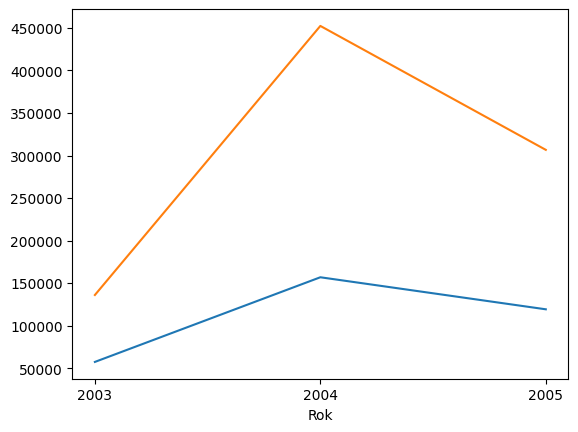

In [26]:
# teraz nieco łatwiej
x = df_zam_sum_by_year_2['Data zamowienia'].unique()
plt.xticks(df_zam_sum_by_year_2['Data zamowienia'].unique())
plt.xlabel('Rok')
plt.plot(x, df_zam_sum_by_year_2[df_zam_sum_by_year_2['Kraj'] == 'Polska'][('Utarg','sum')])
plt.plot(x, df_zam_sum_by_year_2[df_zam_sum_by_year_2['Kraj'] == 'Niemcy'][('Utarg','sum')])

In [27]:
# aby przygotować zgrupowaną ramkę danych tak, aby jeszcze łatwiej było dostać się do serii danych wykorzystamy funkcję unstack()
df_zam_sum_by_year.unstack()

Utarg           
                       sum           
Kraj                Niemcy     Polska
Data zamowienia                      
2003             136002.99   57313.55
2004             452347.15  156843.61
2005             306646.35  119173.75

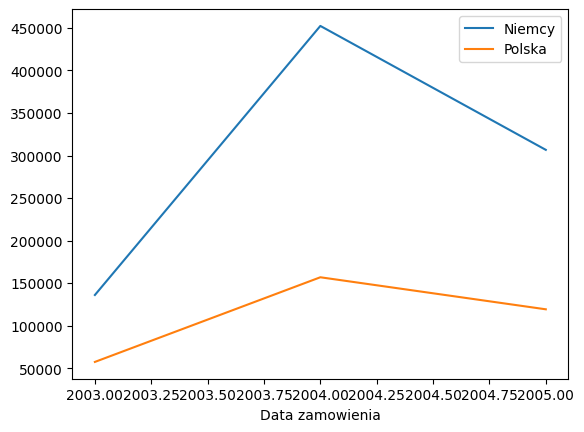

In [28]:
df_zam_sum_by_year_unstacked = df_zam_sum_by_year.unstack()
df_zam_sum_by_year_unstacked.plot()
plt.legend([col[-1] for col in df_zam_sum_by_year_unstacked.columns])

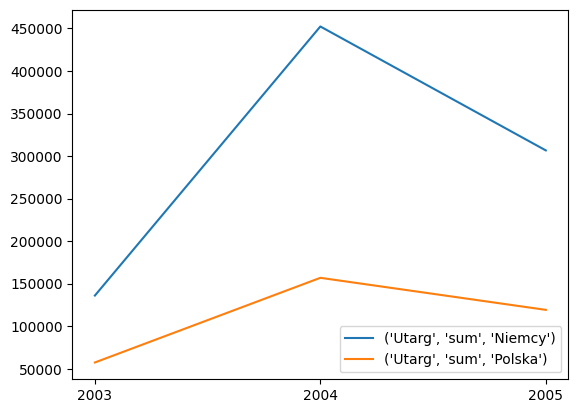

In [29]:
# poprawiamy nieco oś x
plt.xticks(df_zam_sum_by_year_unstacked.index)
plt.plot(df_zam_sum_by_year_unstacked)
plt.legend(df_zam_sum_by_year_unstacked.columns)

### 4. Zadania

**Zadanie 1**

Przygotuj i wyświetl wykres liniowy funkcji f(x) = 1/x dla x ϵ [1, 20]. Dodaj etykietę do linii wykresu i wyświetl legendę. Dodaj odpowiednie etykiety do osi wykresu (‘x’, ’f(x)’) oraz ustaw zakres dla obu osi na (0, 1) oraz (1, długość wektora x).

**Zadanie 2**

Korzystając ze zbioru danych [zamowienia.csv](./data/zamowienia.csv) przygotuj i wyświetl dane w postaci wykresu liniowego z sumą zamówień dla każdego sprzedawcy z Polski w roku 2004 grupując po miesiącach (wzoruj się przykładzie z pkt. 3 tego labu). Każdy wykres to linia dla danego sprzedawcy, a oś x reprezentuje kolejne miesiące roku 2004. Pamiętaj o tym, że można iterować przez zgrupowaną ramkę danych pandas.

**Zadanie 3**

Korzystając z biblioteki pandas wczytaj zbiór danych z [narodzinami dzieci](./data/imiona.xlsx) przygotuj poniższe wykresy:
* 3.1 - wykres słupkowy przedstawiający ilość narodzonych dziewczynek i chłopców w całym okresie.
* 3.2 - wykres liniowy, gdzie będą dwie linie, jedna dla ilości urodzonych kobiet, druga dla mężczyzn dla każdego roku z osobna. Czyli y to ilość narodzonych kobiet lub mężczyzn (dwie linie), x to rok.
* 3.3 - wykres słupkowy przedstawiający sumę urodzonych dzieci w każdym roku.

Dodaj do wykresów stosowne etykiety. Poustawiaj różne kolory dla wykresów.

**Zadanie 4**

Korzystając ze zbioru danych Iris (https://archive.ics.uci.edu/ml/datasets/iris) wygeneruj wykres punktowy, gdzie wektor x to wartość `sepal length` a y to `sepal width`, dodaj paletę kolorów `c` na przykładzie listingu 7, a parametr `s` niech będzie wartością bezwzględną z różnicy wartości poszczególnych elementów wektorów x oraz y. Wykorzystaj bibliotekę pandas do przechowania datasetu.

**Zadanie 5**

Korzystając z pliku [zamowienia.csv](./data/zamowienia.csv), policz sumy zamówień dla każdego sprzedawcy i wyświetl wykres kołowy z procentowym udziałem każdego sprzedawcy w ogólnej sumie zamówień. Poszukaj w Internecie jak dodać cień do takiego wykresu i jak działa atrybut `explode` tego wykresu. Wyświetl wykres podstawowy, z cieniem oraz z jednym elementem z aktywnym atrybutem `explode`.

**Zadanie 6**

Korzystając z galerii matplotlib i [przykładu](https://matplotlib.org/stable/gallery/misc/packed_bubbles.html#sphx-glr-gallery-misc-packed-bubbles-py) postaraj się umieścić analogicznie 10 najbardziej ludnych krajów na świecie w roku 2017 korzystając z danych w pliku [ludność](./data/ludnosc.xlsx).

In [30]:
!pip install openpyxl

Zad 1

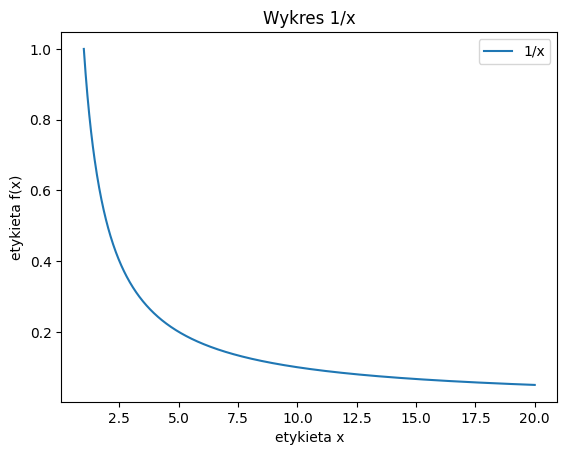

In [35]:
x = np.linspace(1, 20, 1000)

plt.plot(x, 1/x, label='1/x')

plt.xlabel('etykieta x')
plt.ylabel('etykieta f(x)')

plt.title("Wykres 1/x")

plt.legend();

Zad 2

,Kraj,Sprzedawca,Data zamowienia,idZamowienia,Utarg
147,Polska,Sowiński,2004-01-03,10395,2122.92
149,Polska,Kowalski,2004-01-02,10397,716.72
158,Polska,King,2004-01-13,10406,1830.78
163,Polska,Dudek,2004-01-21,10411,966.80
175,Polska,Sowiński,2004-02-24,10423,1020.00
...,...,...,...,...,...
516,Polska,Sowiński,2004-12-08,10764,2286.00
523,Polska,Dudek,2004-01-02,10771,344.00
527,Polska,King,2004-12-26,10775,228.00
534,Polska,Dudek,2004-12-22,10782,12.50


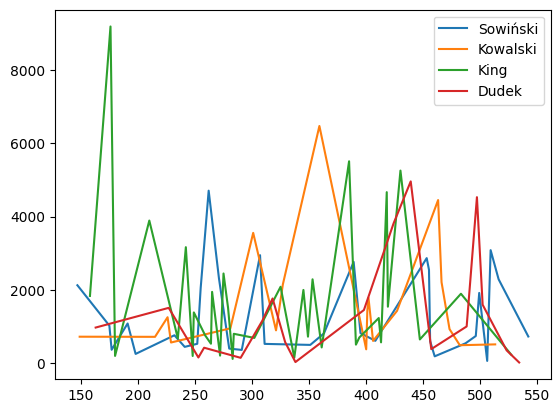

In [36]:
df_zam = pd.read_csv(r'https://raw.githubusercontent.com/kropiak/swps-metody-analizy-danych/refs/heads/main/lab_06/data/zamowienia.csv', sep=';')

df_zam['Data zamowienia'] = pd.to_datetime(df_zam['Data zamowienia'])
df_polska_2004 = df_zam[(df_zam['Kraj'] == 'Polska')]
df_polska_2004 = df_polska_2004[(df_polska_2004['Data zamowienia'].dt.year == 2004)]
display(df_polska_2004)

sprzedawcy_unikalne = df_polska_2004['Sprzedawca'].unique()

for name in sprzedawcy_unikalne:
  sprzedawca_dane = df_polska_2004[df_polska_2004['Sprzedawca'] == name]['Utarg']
  plt.plot(sprzedawca_dane, label=name)
plt.legend();

Zad 3

,Rok,Imie,Liczba,Plec
24,2000,KAROL,3084,M
827,2001,KAROL,2286,M
1627,2002,KAROL,2143,M
2422,2003,KAROL,1830,M
3242,2004,KAROL,1724,M
4073,2005,KAROL,3902,M
4935,2006,KAROL,3812,M
5840,2007,KAROL,3225,M
6796,2008,KAROL,3228,M
7800,2009,KAROL,3117,M


<Axes: >

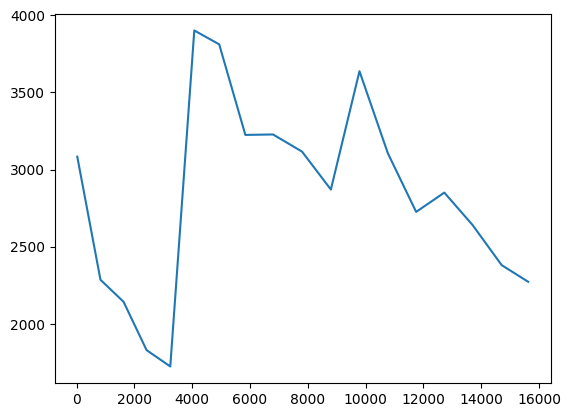

In [37]:
names = pd.read_excel("imiona.xlsx")
display(names[names['Imie'] == 'KAROL'])
names[names['Imie'] == 'KAROL']['Liczba'].plot()

In [38]:
names.groupby('Plec').agg({'Liczba': 'sum'})

,Liczba
Plec,
K,3521321
M,3714961


<Axes: xlabel='Plec'>

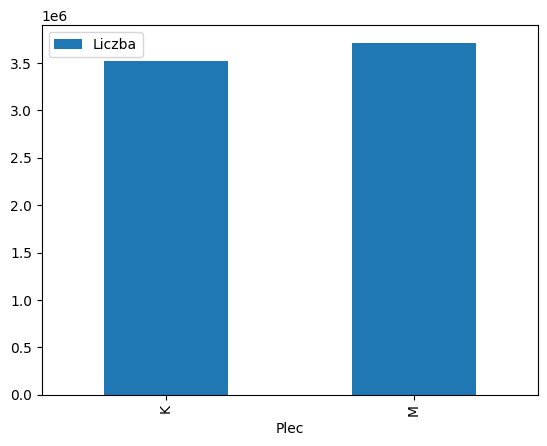

In [39]:
names.groupby('Plec').agg({'Liczba': 'sum'}).plot(kind='bar')

3.2

<Axes: xlabel='Rok'>

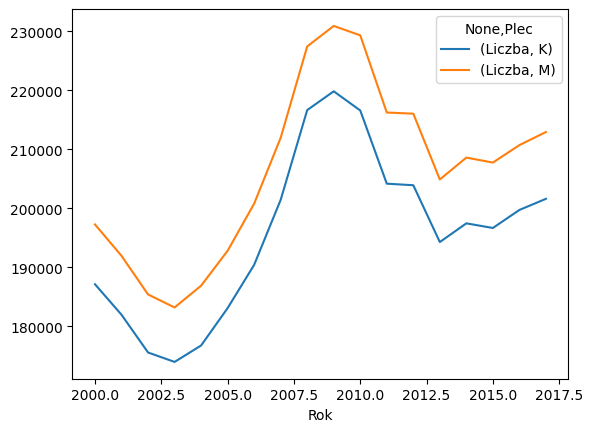

In [40]:
names.groupby(['Rok','Plec']).agg({'Liczba': 'sum'}).unstack().plot(kind='line')

3.3

<Axes: xlabel='Rok'>

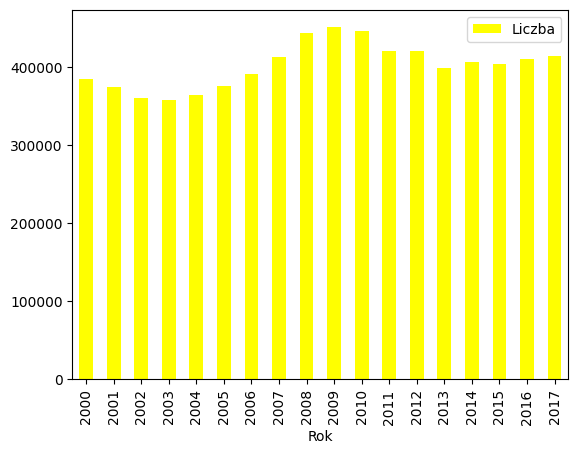

In [41]:
names.groupby('Rok').agg({'Liczba': 'sum'}).plot(kind='bar', color = "yellow")

Zad 4

In [42]:
pip install ucimlrepo

In [43]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)


{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [44]:
iris_complete = pd.concat([X,y], axis=1)
iris_complete.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


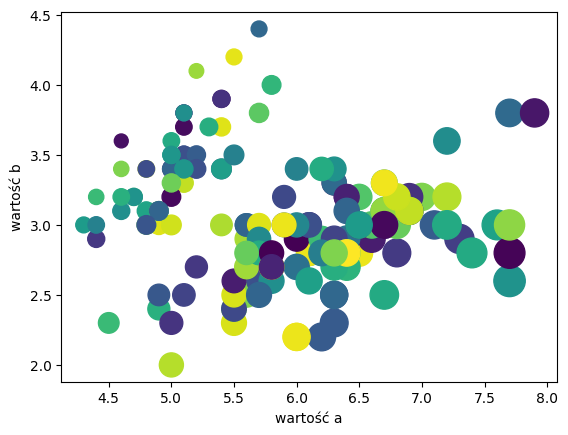

In [45]:
colors = np.random.randint(0, 100, 150)
scaling = 100
size = np.abs(iris_complete['sepal length'] - iris_complete['sepal width']) * scaling

plt.scatter('sepal length' , 'sepal width', c=colors, s=size, data=iris_complete)
plt.xlabel('wartość a')
plt.ylabel('wartość b');

Zad 6

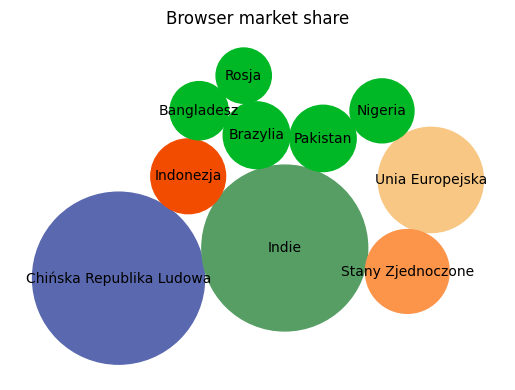

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Import pandas for data manipulation

ludnosc = pd.read_excel('./ludnosc.xlsx') # Load ludnosc here to ensure it's available.
plot_data = ludnosc.loc[:, ['Kraj', 2017]].sort_values(2017, ascending=False).head(10)

browser_market_share = {
    'Kraje': plot_data['Kraj'],
    'Ludnosc': plot_data[2017],
    'color': ['#5A69AF', '#579E65', '#F9C784', '#FC944A', '#F24C00', '#00B825', '#00B825', '#00B825', '#00B825', '#00B825']
}


class BubbleChart:
    def __init__(self, area, bubble_spacing=0):
        """
        Setup for bubble collapse.

        Parameters
        ----------
        area : array-like
            Area of the bubbles.
        bubble_spacing : float, default: 0
            Minimal spacing between bubbles after collapsing.

        Notes
        -----
        If "area" is sorted, the results might look weird.
        """
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # calculate initial grid layout for bubbles
        length = np.ceil(np.sqrt(len(self.bubbles)))
        grid = np.arange(length) * self.maxstep
        gx, gy = np.meshgrid(grid, grid)
        self.bubbles[:, 0] = gx.flatten()[:len(self.bubbles)]
        self.bubbles[:, 1] = gy.flatten()[:len(self.bubbles)]

        self.com = self.center_of_mass()

    def center_of_mass(self):
        return np.average(
            self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3]
        )

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0],
                        bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - \
            bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return np.argmin(distance, keepdims=True)

    def collapse(self, n_iterations=50):
        """
        Move bubbles to the center of mass.

        Parameters
        ----------
        n_iterations : int, default: 50
            Number of moves to perform.
        """
        for _i in range(n_iterations):
            moves = 0
            for i in range(len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                # try to move directly towards the center of mass
                # direction vector from bubble to the center of mass
                dir_vec = self.com - self.bubbles[i, :2]

                # shorten direction vector to have length of 1
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))

                # calculate new bubble position
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                # check whether new bubble collides with other bubbles
                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    # try to move around a bubble that you collide with
                    # find colliding bubble
                    for colliding in self.collides_with(new_bubble, rest_bub):
                        # calculate direction vector
                        dir_vec = rest_bub[colliding, :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        # calculate orthogonal vector
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        # test which direction to go
                        new_point1 = (self.bubbles[i, :2] + orth *
                                      self.step_dist)
                        new_point2 = (self.bubbles[i, :2] - orth *
                                      self.step_dist)
                        dist1 = self.center_distance(
                            self.com, np.array([new_point1]))
                        dist2 = self.center_distance(
                            self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2

    def plot(self, ax, labels, colors):
        """
        Draw the bubble plot.

        Parameters
        ----------
        ax : matplotlib.axes.Axes
        labels : list
            Labels of the bubbles.
        colors : list
            Colors of the bubbles.
        """
        for i in range(len(self.bubbles)):
            circ = plt.Circle(
                self.bubbles[i, :2], self.bubbles[i, 2], color=colors[i])
            ax.add_patch(circ)
            ax.text(*self.bubbles[i, :2], labels[i],
                    horizontalalignment='center', verticalalignment='center')


bubble_chart = BubbleChart(area=browser_market_share['Ludnosc'],
                           bubble_spacing=0.1)

bubble_chart.collapse()

fig, ax = plt.subplots(subplot_kw=dict(aspect="equal"))
bubble_chart.plot(
    ax, browser_market_share['Kraje'], browser_market_share['color'])
ax.axis("off")
ax.relim()
ax.autoscale_view()
ax.set_title('Browser market share')

plt.show()

In [53]:
ludnosc = pd.read_excel('./ludnosc.xlsx')
display(ludnosc)

,Kraj,2006,2007,2008,2009,2011,2012,2016,2017
0,Chińska Republika Ludowa,1.314480e+09,1.321290e+09,1.328020e+09,1.338613e+09,1.336718e+09,1.343240e+09,1.373541e+09,1.379303e+09
1,Indie,1.095352e+09,1.129866e+09,1.147996e+09,1.166079e+09,1.189173e+09,1.205074e+09,1.266884e+09,1.281936e+09
2,Unia Europejska,4.866422e+08,4.904261e+08,4.910187e+08,4.915829e+08,4.923873e+08,5.038244e+08,5.150528e+08,5.161954e+08
3,Stany Zjednoczone,2.984442e+08,3.011399e+08,3.055480e+08,3.072121e+08,3.132320e+08,3.138475e+08,3.239955e+08,3.266258e+08
4,Indonezja,2.454527e+08,2.346940e+08,2.375124e+08,2.402715e+08,2.456130e+08,2.482162e+08,2.583161e+08,2.605807e+08
...,...,...,...,...,...,...,...,...,...
237,Pitcairn,4.500000e+01,4.800000e+01,4.800000e+01,4.800000e+01,4.800000e+01,4.800000e+01,5.400000e+01,NaN
238,Majotta,2.012340e+05,2.087830e+05,2.163060e+05,2.237650e+05,NaN,NaN,NaN,NaN
239,Dhekelia,NaN,NaN,1.570000e+04,1.570000e+04,1.570000e+04,1.570000e+04,NaN,NaN
240,Akrotiri,NaN,NaN,1.570000e+04,1.570000e+04,1.570000e+04,1.570000e+04,NaN,NaN
